In [5]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip install torch

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.2/865.2 MB 5.7 MB/s eta 0:00:00m eta 0:00:010:00:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 6.1 MB/s eta 0:00:00m eta 0:00:010:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 6.4 MB/s eta 0:00:00 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 6.4 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 6.1 MB/s eta 0:00:00m eta 0:00:010:00:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 6.6 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 6.6 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 6.5 MB/s eta 0:

!pip install torchvision

In [9]:
!pip install torchvision

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 7.0 MB/s eta 0:00:000:00:01m eta 0:00:01


In [2]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
import torchvision.transforms.functional as F
from torch.utils.data import DataLoader
from torchvision.io import read_image
from torchvision import models, datasets, transforms

In [2]:
ip = 'http://192.168.0.10:8080/video'

In [3]:
cap = cv2.VideoCapture('http://192.168.0.10:8080/video')
if not cap.isOpened():
    print('Failed to open video capture')
else:
    print('stream opened successfully')
ret, bac = cap.read()
print(bac.shape)

stream opened successfully
(480, 640, 3)


In [4]:
weights = models.detection.SSD300_VGG16_Weights.COCO_V1
ssd300 = models.detection.ssd300_vgg16(weights=weights)
ssd300.eval()

wewe = models.detection.FasterRCNN_MobileNet_V3_Large_320_FPN_Weights
mobile_net = models.detection.fasterrcnn_mobilenet_v3_large_320_fpn(weights=wewe)

mobile_net.eval()

/home/park/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_MobileNet_V3_Large_320_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_MobileNet_V3_Large_320_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(320,), max_size=640, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): FrozenBatchNorm2d(16, eps=1e-05)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
          )
        )
      )
      (2): InvertedResidual(
        (block): 

In [ ]:
while True:
    ret, frame = cap.read()
    if not ret:
        break
    

    # img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # (1080, 1920, 3)
    img_resized = cv2.resize(frame, (300, 300))  # (300, 300, 3)
    img_chw = np.transpose(img_resized, (2, 0, 1))  # (3, 300, 300)
    img_batched = np.expand_dims(img_chw, axis=0)  # (1, 3, 300, 300)
    bac_t = torch.tensor(img_batched, dtype=torch.float32)


    image = img_resized
    with torch.no_grad():
        prediction = mobile_net(bac_t)
    prediction = prediction[0]  
    for box, label, score in zip(prediction["boxes"], prediction["labels"], prediction["scores"]):
        if score > 0.9:
            box = list(map(int, box))
            print(box)
            cv2.rectangle(image, (box[0], box[1]), (box[2], box[3]), (255, 0, 0), 2, cv2.LINE_AA)
    
    cv2.imshow('frame',image)
    if cv2.waitKey(20) == 27:
        break

[27, 281, 199, 286]
[280, 208, 287, 208]
[282, 211, 289, 211]
[284, 210, 288, 210]
[297, 0, 299, 110]
[5, 278, 240, 281]


: 

# 아래는 테스트 코드 

In [5]:
mobile_net.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(320,), max_size=640, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): FrozenBatchNorm2d(16, eps=1e-05)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
          )
        )
      )
      (2): InvertedResidual(
        (block): 

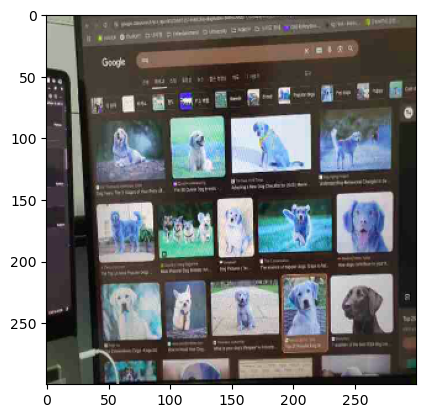

In [13]:
# img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # (1080, 1920, 3)
img_resized = cv2.resize(frame, (300, 300))  # (300, 300, 3)
img_chw = np.transpose(img_resized, (2, 0, 1))  # (3, 300, 300)
img_batched = np.expand_dims(img_chw, axis=0)  # (1, 3, 300, 300)
bac_t = torch.tensor(img_batched, dtype=torch.float32)


image = img_resized

plt.imshow(image)

In [14]:
dede = mobile_net(bac_t)

In [16]:
dede = dede[0]

In [19]:
dede['boxes']

tensor([], size=(0, 4), grad_fn=<StackBackward0>)

In [5]:
transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor()
])

In [20]:
cap = cv2.VideoCapture('http://192.168.0.10:8080/video')
if not cap.isOpened():
    print('Failed to open video capture')
else:
    print('stream opened successfully')
ret, bac = cap.read()


img_rgb = cv2.cvtColor(bac, cv2.COLOR_BGR2RGB)  # (1080, 1920, 3)
img_resized = cv2.resize(img_rgb, (300, 300))  # (300, 300, 3)
img_chw = np.transpose(img_resized, (2, 0, 1))  # (3, 300, 300)
img_batched = np.expand_dims(img_chw, axis=0)  # (1, 3, 300, 300)
bac_t = torch.tensor(img_batched, dtype=torch.float32)

stream opened successfully


In [23]:
ssd300.eval()

SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

In [24]:
with torch.no_grad():
    prediction = ssd300(bac_t)

In [28]:
image = img_resized
# prediction = prediction[0]
for box, label, score in zip(prediction["boxes"], prediction["labels"], prediction["scores"]):
    if score > 0.9:
        box = list(map(int, box))
        print(box)
        cv2.rectangle(image, (box[0], box[1]), (box[2], box[3]), (255, 0, 0), 2, cv2.LINE_AA)

[300, 0, 300, 300]
[300, 300, 300, 300]
[300, 300, 300, 300]
[300, 300, 300, 300]
[300, 0, 300, 300]
[300, 0, 300, 300]
[0, 300, 300, 300]
[0, 0, 300, 300]
[300, 0, 300, 300]
[300, 0, 300, 300]
[300, 0, 300, 0]
[0, 300, 0, 300]
[0, 0, 0, 300]
[0, 0, 0, 300]


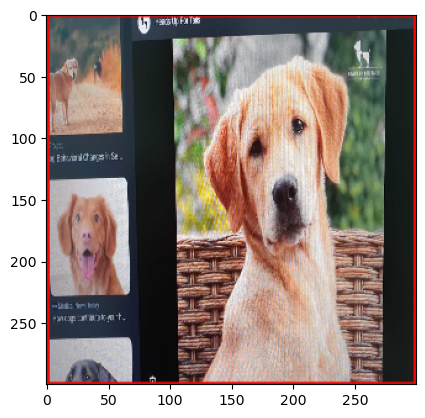

In [29]:
plt.imshow(image)